# 原生 LightGBM × Experiment 完整指南 · 0.9.4

**训练代码就是原生 LightGBM。** Experiment 只提供方法空间、Run 生命周期、参数/指标/文件记录、恢复与比较。删去记录语句后，Dataset、train、callbacks、predict、cv 仍可独立运行。

本教程使用 100,000 行 × 60 个输入特征，实际运行 CPU 二分类、回归、多分类、自定义 loss、callbacks、继续训练、类别/缺失值、稀疏输入、CV、RFE 与 ranking。GPU 提供可选分支，本次不宣称 GPU 已验证。

参考：[Python 入门](https://lightgbm.readthedocs.io/en/v4.0.0/Python-Intro.html)、[train](https://lightgbm.readthedocs.io/en/v4.0.0/pythonapi/lightgbm.train.html)、[参数](https://lightgbm.readthedocs.io/en/v4.0.0/Parameters.html)。

主线：**baseline.yaml 保持不变 → 派生多套完整配置 → 选择一套原生训练 → 每次执行保存为 Run → 比较。** 配置方案与 Run 不一一绑定，同一配置可以重复执行。

## 1. 环境与初始化

安装项目 lightgbm/hydra extras，以及 notebook 所需 nbformat、nbclient、ipykernel、matplotlib。推荐使用较新的 LightGBM 4.x。

LightGBM 4.0–4.5 与当前仓库较新的 NumPy/pandas/sklearn 存在接口差异。下面显式选择已有兼容辅助函数；它不封装 train，但会调整 LightGBM 内部持有的旧接口引用。并不是纯原生 4.0 自动兼容所有新依赖。

`initialize` 创建方法空间，不创建训练器。不安装 XGBoost/PyTorch 也可以创建它们的目录；这不代表已训练这些模型。

In [1]:
import platform
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from scipy import sparse
from scipy.special import expit
from sklearn.metrics import log_loss, mean_absolute_error, mean_squared_error

from phl_risk.metrics import auc_score
from phl_risk.modeling.experiment import Experiment, Run
from phl_risk.modeling.experiment.adapters.hydra import compose_config
from phl_risk.modeling.experiment.adapters.lightgbm import (
    enable_lightgbm_compatibility,
    load_lightgbm,
    record_lightgbm,
)

if tuple(int(v) for v in lgb.__version__.split(".")[:2]) < (4, 6):
    enable_lightgbm_compatibility()
REPO = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").exists())
exp = Experiment(root=REPO / "experiments")
space = (
    exp.open_method("lgb")
    if (exp.path / "lgb" / "method.json").exists()
    else exp.initialize(method="lgb", objective="binary", metric=["auc", "binary_logloss"])
)
xgb_space = exp.initialize(method="xgb", family="tree")
print("Parallel model spaces:", space.path, xgb_space.path)
print("Native LightGBM:", lgb.__version__, "Host:", platform.system(), platform.machine())
SEED = 2026
rng = np.random.default_rng(SEED)
plt.rcParams.update({"figure.figsize": (9, 4), "font.size": 11})
RUN_GPU = False  # Only enable after verifying the LightGBM build, drivers and device.
created = []

Parallel model spaces: /Users/xuetao/git_code/phi_risk/experiments/lgb /Users/xuetao/git_code/phi_risk/experiments/xgb
Native LightGBM: 4.7.0 Host: Darwin arm64


## 2. 准备数据：框架不接管切分或标签

60 个连续输入特征；另有 binary/regression/multiclass target 和样本权重，均不进入 features。
train=60,000、valid=20,000、test=10,000、oot_demo=10,000。
`oot_demo` 是 IID 示例，不能替代真实时间外数据。真实项目需自行保证时间/用户隔离、预处理仅在 train 拟合。

数据不自动保存；请在 metadata 中记录真实数据版本、查询或文件校验信息。

In [2]:
features = [f"feature_{i:02d}" for i in range(60)]
X = rng.normal(size=(100_000, 60)).astype("float32")
signal = 1.2 * X[:, 0] - X[:, 1] + 0.7 * X[:, 2] * X[:, 3]
data = pd.DataFrame(X, columns=features)
data["binary"] = rng.binomial(1, expit(signal))
data["regression"] = 4 * signal + rng.normal(scale=1.5, size=len(data))
data["multiclass"] = np.digitize(signal, [-0.7, 0.7])
data["weight"] = rng.uniform(0.5, 1.5, size=len(data))
parts = {
    "train": data.iloc[:60_000],
    "valid": data.iloc[60_000:80_000],
    "test": data.iloc[80_000:90_000],
    "oot_demo": data.iloc[90_000:],
}
train, valid = parts["train"], parts["valid"]
metadata = {
    "data_version": "synthetic-native-guide-v1",
    "seed": SEED,
    "code_revision": "native-guide-v1",
}
pd.DataFrame({"partition": list(parts), "rows": [len(p) for p in parts.values()]})

,partition,rows
0,train,60000
1,valid,20000
2,test,10000
3,oot_demo,10000


## 3. 先准备三套独立配置，再训练

baseline.yaml 是公共基础，下面三个 compose_config 调用分别读取它，各自得到完整参数，不会写回原文件。
Hydra 的 overrides 指派生时替换新配置中的字段，不是覆盖磁盘上的 baseline。

- baseline_cfg：基础模型参数。
- depth3_cfg：只调整树深。
- depth3_lr_cfg：调整树深和学习率。

共同的 train 设置仅为教程缩短执行时间，三套方案都使用相同训练预算。
metric 可以是列表，objective 可以是字符串或真实函数（后文演示）。
`params` 传给原生 LightGBM；`train` 由 Python 显式读取。不要在 params 中再设置 num_iterations 等轮数别名。

每次 compose 返回独立字典，但 `other = baseline_cfg` 仍是普通 Python 引用，不会复制对象。准备完配置后再 start_run，避免记录和实际执行分叉。

In [3]:
config_path = space.config_dir / "baseline.yaml"
baseline_text = config_path.read_text()
shared_training_overrides = [
    "train.num_boost_round=140",
    "train.early_stopping.stopping_rounds=20",
    "train.log_evaluation.period=0",
]
baseline_cfg = compose_config(
    config_dir=space.config_dir,
    config_name="baseline",
    overrides=shared_training_overrides,
)
depth3_cfg = compose_config(
    config_dir=space.config_dir,
    config_name="baseline",
    overrides=[*shared_training_overrides, "params.max_depth=3"],
)
depth3_lr_cfg = compose_config(
    config_dir=space.config_dir,
    config_name="baseline",
    overrides=[*shared_training_overrides, "params.max_depth=3", "params.learning_rate=0.03"],
)
configuration_sets = {
    "baseline": baseline_cfg,
    "depth3": depth3_cfg,
    "depth3_lr": depth3_lr_cfg,
}
assert config_path.read_text() == baseline_text
assert baseline_cfg.config["params"]["max_depth"] == 4
assert depth3_cfg.config["params"]["learning_rate"] == 0.05
assert depth3_lr_cfg.config["params"]["learning_rate"] == 0.03
display(
    pd.DataFrame(
        [
            {
                "configuration": name,
                **{
                    key: item.config["params"][key]
                    for key in ["max_depth", "learning_rate", "metric"]
                },
            }
            for name, item in configuration_sets.items()
        ]
    )
)
# 选择本次执行的配置。其他两套已经准备好，之后可以直接使用。
selected_config = configuration_sets["baseline"]
cfg = selected_config.config
params = cfg["params"]

,configuration,max_depth,learning_rate,metric
0,baseline,4,0.05,"[auc, binary_logloss]"
1,depth3,3,0.05,"[auc, binary_logloss]"
2,depth3_lr,3,0.03,"[auc, binary_logloss]"


## 4. Baseline：原生 Dataset → train → Booster

Run 上下文内任意 Python 代码都可运行。正常退出并成功提交文件才标记 completed；异常或 KeyboardInterrupt 标记 failed；进程被强杀时可能留下 running，需要人工调查。

`log_input` 是描述信息，不会验证标签或改变数据。`record_lightgbm` 只保存模型、特征名、指定轮数与 importance；它不训练、不预测、不计算指标。

下面显式用 best_iteration 预测并保存，保证指标和保存模型轮数一致。history 来自原生 record_evaluation callback，需要用户明确添加。

配置块仅包含原生 callback 参数，可以直接 `lgb.early_stopping(**cfg["train"]["early_stopping"])`。`**` 将字典展开为函数关键字参数。不使用某个 callback 时，直接从 callbacks 列表移除，不在 YAML 保留 enabled 开关。日志 period=0 是 LightGBM 原生的静默方式。

In [4]:
with space.start_run(
    name="cpu_baseline",
    config=selected_config,
    metadata={**metadata, "configuration_name": "baseline"},
    comparison_partitions=["train", "valid"],
) as attempt:
    attempt.log_input(
        target="binary",
        weight="weight",
        features=features,
        partitions={name: {"rows": len(part)} for name, part in parts.items()},
    )
    train_set = lgb.Dataset(train[features], label=train.binary, weight=train.weight)
    valid_set = train_set.create_valid(valid[features], label=valid.binary, weight=valid.weight)
    history = {}
    model = lgb.train(
        params=cfg["params"],
        train_set=train_set,
        num_boost_round=cfg["train"]["num_boost_round"],
        valid_sets=[train_set, valid_set],
        valid_names=["train", "valid"],
        callbacks=[
            lgb.record_evaluation(history),
            lgb.early_stopping(**cfg["train"]["early_stopping"]),
            lgb.log_evaluation(**cfg["train"]["log_evaluation"]),
        ],
    )
    iteration = model.best_iteration or model.current_iteration()
    scores = {}
    for name, part in parts.items():
        prediction = model.predict(part[features], num_iteration=iteration, num_threads=4)
        scores[name] = {
            "auc": auc_score(part.binary, prediction, sample_weight=part.weight),
            "logloss": log_loss(part.binary, prediction, sample_weight=part.weight),
        }
    attempt.log_metrics(scores)
    attempt.log_json("eval_history", history)
    record_lightgbm(attempt, model, num_iteration=iteration)
baseline = attempt.record
created.append(baseline.run)
print(f"Recorded: {attempt.record.run} | name={attempt.record.name}")
binary_runs = [baseline.run]
display(space.compare(runs=binary_runs, metrics=["auc"], params=["max_depth", "num_leaves"]))

Recorded: lgb_run_17 | name=cpu_baseline


,run,name,created_at,objective,metric,train_auc,valid_auc,params
0,lgb_run_17,cpu_baseline,2026-09-27T22:25:45.194712+08:00,binary,"[auc, binary_logloss]",0.819129,0.812458,"{'max_depth': 4, 'num_leaves': 15}"


## 5. 原生诊断和文件访问

Run 是不可变的结果；模型通过适配器或直接 `lgb.Booster(model_file=...)` 加载。读取 history/importance 不需要重新训练。
原生 `dump_model`、`feature_importance`、`predict(pred_leaf=True)` 不经过 framework。
默认比较只显示本 Run 指定的 train/valid；test 和 oot_demo 已记录，但要显式选择才显示。

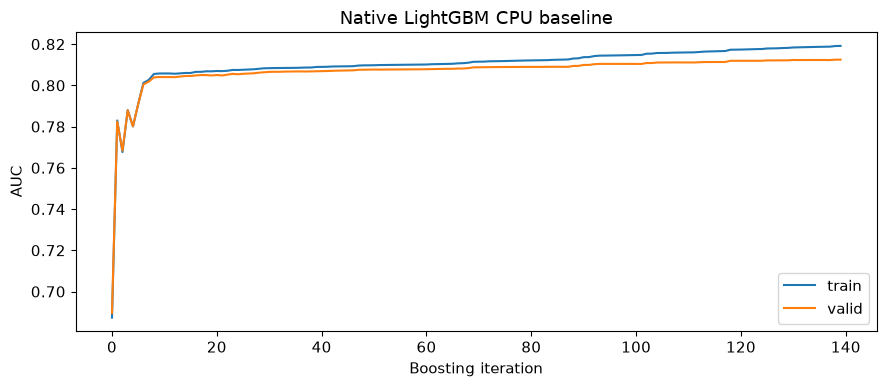

Leaf matrix: (5, 140)
Trees in dump: 140


,feature,importance_gain,importance_split,gain_rank,split_rank
0,feature_00,93721.183756,416,1,2
1,feature_01,65800.904384,478,2,1
2,feature_03,4399.791405,96,3,4
3,feature_02,3084.359564,113,4,3
4,feature_42,219.557838,24,5,6
5,feature_45,218.085070,25,6,5
6,feature_46,203.492819,20,7,7
7,feature_44,196.816892,18,8,10


In [5]:
loaded = load_lightgbm(baseline)
for name in ["train", "valid"]:
    plt.plot(history[name]["auc"], label=name)
plt.title("Native LightGBM CPU baseline")
plt.xlabel("Boosting iteration")
plt.ylabel("AUC")
plt.legend()
plt.tight_layout()
plt.show()
print("Leaf matrix:", loaded.predict(valid[features].head(5), pred_leaf=True).shape)
print("Trees in dump:", len(loaded.dump_model()["tree_info"]))
display(pd.read_csv(baseline.artifact_path("feature_importance")).head(8))

## 6. 使用已经准备好的两套派生配置

无需重新改字典或写回 baseline：依次选择 depth3_cfg、depth3_lr_cfg，使用同一段原生代码训练。
每次建立新的 Dataset 和 callbacks。Run 保存配置名称（metadata）、完整参数、派生记录、模型及指标。
下面的循环只是普通 Python，不引入自动调参。可以只选择一套，也可以重复执行同一套。

In [6]:
for configuration_name in ["depth3", "depth3_lr"]:
    selected_config = configuration_sets[configuration_name]
    cfg = selected_config.config
    with space.start_run(
        name=configuration_name,
        config=selected_config,
        metadata={**metadata, "configuration_name": configuration_name},
        comparison_partitions=["train", "valid"],
    ) as attempt:
        ds = lgb.Dataset(train[features], label=train.binary, weight=train.weight)
        dv = ds.create_valid(valid[features], label=valid.binary, weight=valid.weight)
        trace = {}
        changed_model = lgb.train(
            params=cfg["params"],
            train_set=ds,
            num_boost_round=cfg["train"]["num_boost_round"],
            valid_sets=[ds, dv],
            valid_names=["train", "valid"],
            callbacks=[
                lgb.record_evaluation(trace),
                lgb.early_stopping(**cfg["train"]["early_stopping"]),
                lgb.log_evaluation(**cfg["train"]["log_evaluation"]),
            ],
        )
        chosen = changed_model.best_iteration or changed_model.current_iteration()
        attempt.log_metrics(
            {
                name: {
                    "auc": auc_score(
                        part.binary,
                        changed_model.predict(part[features], num_iteration=chosen, num_threads=4),
                        sample_weight=part.weight,
                    )
                }
                for name, part in {"train": train, "valid": valid}.items()
            }
        )
        attempt.log_json("eval_history", trace)
        record_lightgbm(attempt, changed_model, num_iteration=chosen)
    changed = attempt.record
    created.append(changed.run)
    print(f"Recorded: {attempt.record.run} | name={attempt.record.name}")
    binary_runs.append(changed.run)
    display(space.compare_params(baseline.run, changed.run))
assert config_path.read_text() == baseline_text

Recorded: lgb_run_18 | name=depth3


,parameter,lgb_run_17,lgb_run_18,change,left_present,right_present
0,params.max_depth,4,3,modified,True,True


Recorded: lgb_run_19 | name=depth3_lr


,parameter,lgb_run_17,lgb_run_19,change,left_present,right_present
0,params.learning_rate,0.05,0.03,modified,True,True
1,params.max_depth,4,3,modified,True,True


### 6.1 将一套方案另存为独立 YAML

`ComposedConfig.save(path)` 导出完整解析后的参数，不修改 baseline，也拒绝覆盖已有文件。
临时探索直接用配置对象；值得复用的方案可另存。重复执行本单元格会读取并核对已有文件，不悄悄替换。

导出后可通过 compose_config 读取新 YAML 再派生，或直接用 read_yaml_config 读取用于训练。
导出的文件是完整快照，不会随以后 baseline 改动而变化；它不包含历史 overrides。
要保留原始派生来源，当前 Run 直接接收 depth3_lr_cfg 即可。函数只导出身份，重新读取后仍需手工绑定。

In [7]:
from phl_risk.modeling.experiment.adapters.yaml import read_yaml_config

saved_config_path = space.config_dir / "depth3_lr.yaml"
if not saved_config_path.exists():
    depth3_lr_cfg.save(saved_config_path)
restored_cfg = read_yaml_config(saved_config_path)
assert restored_cfg == depth3_lr_cfg.config
assert config_path.read_text() == baseline_text
print("Reusable complete configuration:", saved_config_path)
print("To run: select restored_cfg, then start_run(config=restored_cfg).")

Reusable complete configuration: /Users/xuetao/git_code/phi_risk/experiments/lgb/configs/depth3_lr.yaml
To run: select restored_cfg, then start_run(config=restored_cfg).


### 6.2 自建另一个 YAML 文件

你也可以编辑 configs 下的新文件，无需 Hydra。读出字典直接训练，`config=path` 会保存读取时的原文件和参数。
若读取后在 Python 改动参数，则应传入修改后的字典 `config=cfg`，不要仍传旧路径。
本例不传 early_stopping callback，明确跑完 40 轮。

In [8]:
from phl_risk.modeling.experiment.adapters.yaml import read_yaml_config

alternative_path = space.config_dir / "alternative.yaml"
if not alternative_path.exists():
    alternative = yaml.safe_load(config_path.read_text())
    alternative["params"].update({"max_depth": 3, "num_leaves": 7, "learning_rate": 0.08})
    alternative["train"]["num_boost_round"] = 40
    alternative["train"].pop("early_stopping")  # 本例不使用早停。
    alternative["train"]["log_evaluation"]["period"] = 0
    alternative_path.write_text(yaml.safe_dump(alternative, sort_keys=False))
alternative = read_yaml_config(alternative_path)
with space.start_run(
    name="external_yaml",
    config=alternative_path,
    metadata=metadata,
    comparison_partitions=["valid"],
) as attempt:
    ds = lgb.Dataset(train[features], label=train.binary, weight=train.weight)
    dv = ds.create_valid(valid[features], label=valid.binary, weight=valid.weight)
    trace = {}
    alternative_model = lgb.train(
        alternative["params"],
        ds,
        num_boost_round=alternative["train"]["num_boost_round"],
        valid_sets=[dv],
        valid_names=["valid"],
        callbacks=[
            lgb.record_evaluation(trace),
            lgb.log_evaluation(**alternative["train"]["log_evaluation"]),
        ],
    )
    chosen = alternative_model.best_iteration or alternative_model.current_iteration()
    prediction = alternative_model.predict(valid[features], num_iteration=chosen, num_threads=4)
    attempt.log_metrics(
        {"valid": {"auc": auc_score(valid.binary, prediction, sample_weight=valid.weight)}}
    )
    attempt.log_json("eval_history", trace)
    record_lightgbm(attempt, alternative_model, num_iteration=chosen)
created.append(attempt.record.run)
print(f"Recorded: {attempt.record.run} | name={attempt.record.name}")
binary_runs.append(attempt.record.run)
display(
    space.compare_params(baseline.run, attempt.record.run, params=["max_depth", "learning_rate"])
)

Recorded: lgb_run_20 | name=external_yaml


,parameter,lgb_run_17,lgb_run_20,change,left_present,right_present
0,params.learning_rate,0.05,0.08,modified,True,True
1,params.max_depth,4,3,modified,True,True


## 7. Callbacks：动态学习率、日志与观察

直接传递 LightGBM callbacks。这里使用 reset_parameter、record_evaluation、log_evaluation 和自定义 observer。每次训练创建新的 callback 对象，避免复用其状态。

框架不拦截 callback，也不强制 early stopping。本例明确训练 60 轮。动态调度需要保存代码，最后一轮 learning_rate 不能代表整个学习率计划。

In [9]:
seen = []


def learning_rate_schedule(i):
    return 0.05 * 0.98**i


def observe(env):
    seen.append(env.iteration)


with space.start_run(
    name="callback_schedule",
    config={
        "params": params,
        "train": {"num_boost_round": 60, "learning_rate_schedule": learning_rate_schedule},
    },
    metadata=metadata,
    comparison_partitions=["valid"],
) as attempt:
    ds = lgb.Dataset(train[features], label=train.binary, weight=train.weight)
    dv = ds.create_valid(valid[features], label=valid.binary, weight=valid.weight)
    trace = {}
    scheduled = lgb.train(
        params,
        ds,
        num_boost_round=60,
        valid_sets=[dv],
        valid_names=["valid"],
        callbacks=[
            lgb.reset_parameter(learning_rate=learning_rate_schedule),
            lgb.record_evaluation(trace),
            lgb.log_evaluation(30),
            observe,
        ],
    )
    p = scheduled.predict(
        valid[features], num_iteration=scheduled.current_iteration(), num_threads=4
    )
    attempt.log_metrics({"valid": {"auc": auc_score(valid.binary, p, sample_weight=valid.weight)}})
    attempt.log_json("eval_history", trace)
    record_lightgbm(attempt, scheduled, num_iteration=scheduled.current_iteration())
assert len(seen) == 60
created.append(attempt.record.run)
print(f"Recorded: {attempt.record.run} | name={attempt.record.name}")
binary_runs.append(attempt.record.run)
print("Observed:", len(seen), "native callbacks")

[30]	valid's auc: 0.805911	valid's binary_logloss: 0.576438


[60]	valid's auc: 0.806882	valid's binary_logloss: 0.554766
Recorded: lgb_run_21 | name=callback_schedule
Observed: 60 native callbacks


## 8. 回归与分位数：更换原生 objective

不需要声明框架 task；原生 objective 直接决定训练。下面普通回归用 L2、报告 RMSE/MAE；quantile 用 alpha=0.9、报告 pinball loss。不要把不同 target 或不同指标放到一张表里自动排序选优。

In [10]:
reg_runs = []
for objective in ["regression", "quantile"]:
    reg_params = {
        **params,
        "objective": objective,
        "metric": "rmse" if objective == "regression" else "quantile",
    }
    if objective == "quantile":
        reg_params["alpha"] = 0.9
    with space.start_run(
        name=objective,
        config={"params": reg_params, "train": {"num_boost_round": 120}},
        metadata={**metadata, "target": "regression"},
        comparison_partitions=["valid"],
    ) as attempt:
        ds = lgb.Dataset(train[features], label=train.regression, weight=train.weight)
        dv = ds.create_valid(valid[features], label=valid.regression, weight=valid.weight)
        reg_model = lgb.train(
            reg_params, ds, num_boost_round=120, valid_sets=[dv], valid_names=["valid"]
        )
        p = reg_model.predict(
            valid[features], num_iteration=reg_model.current_iteration(), num_threads=4
        )
        if objective == "regression":
            values = {
                "rmse": np.sqrt(
                    mean_squared_error(valid.regression, p, sample_weight=valid.weight)
                ),
                "mae": mean_absolute_error(valid.regression, p, sample_weight=valid.weight),
            }
        else:
            residual = valid.regression.to_numpy() - p
            values = {
                "pinball_90": np.average(
                    np.maximum(0.9 * residual, -0.1 * residual), weights=valid.weight
                )
            }
        attempt.log_metrics({"valid": values})
        record_lightgbm(attempt, reg_model, num_iteration=reg_model.current_iteration())
    created.append(attempt.record.run)
    print(f"Recorded: {attempt.record.run} | name={attempt.record.name}")
    reg_runs.append(attempt.record.run)
display(space.compare(runs=reg_runs, params=["alpha"]))

Recorded: lgb_run_22 | name=regression


Recorded: lgb_run_23 | name=quantile


,run,name,created_at,objective,metric,valid_mae,valid_pinball_90,valid_rmse,params
0,lgb_run_22,regression,2026-09-27T22:25:47.709084+08:00,regression,rmse,2.175625,NaN,3.030013,{'alpha': None}
1,lgb_run_23,quantile,2026-09-27T22:25:48.052602+08:00,quantile,quantile,NaN,0.413723,NaN,{'alpha': 0.9}


## 9. 自定义 loss 与 feval：直接放入原生接口

LightGBM 4.x 的自定义 objective 为 `(raw_predictions, Dataset) -> gradient, hessian`；feval 返回 `(name, value, higher_is_better)`。自定义 logistic loss 需自行应用权重。

这里 objective 直接是函数，无 Hooks 对象。训练与加载后的 Booster 返回 raw margin，需要显式 sigmoid。记录函数身份和可获得的源码 hash，不能自动还原闭包、外部状态或实现；代码版本必须另行保留。
初始化也可以直接传 `objective=logistic_loss`（函数本身）。YAML 只保存身份/源码摘要，不能重建函数。
下面在独立示例项目中验证这条路径，然后通过 Hydra 改参数并手工绑定真实函数。不使用自动 import 或 eval。

In [11]:
def logistic_loss(raw, dataset):
    p = expit(raw)
    w = dataset.get_weight()
    if w is None:
        w = np.ones_like(p)
    return (p - dataset.get_label()) * w, np.maximum(p * (1 - p), 1e-12) * w


def logistic_feval(raw, dataset):
    value = log_loss(
        dataset.get_label(), expit(raw), sample_weight=dataset.get_weight(), labels=[0, 1]
    )
    return "weighted_logloss", float(value), False


custom_project = Experiment(root=exp.path / "custom_objective_demo")
custom_space = (
    custom_project.open_method("lgb")
    if (custom_project.path / "lgb" / "method.json").exists()
    else custom_project.initialize(method="lgb", objective=logistic_loss, metric="None")
)
custom_config = compose_config(
    config_dir=custom_space.config_dir,
    config_name="baseline",
    overrides=[
        "params.learning_rate=0.04",
        "train.num_boost_round=100",
        "~train.early_stopping",
        "~train.log_evaluation",
    ],
)
custom_config.config["params"]["objective"] = (
    logistic_loss  # 绑定真实函数，不把描述字典传给 lgb.train。
)
custom_config.config["train"].update({"feval": logistic_feval, "prediction_transform": expit})
custom_params = custom_config.config["params"]
with space.start_run(
    name="custom_logistic", config=custom_config, metadata=metadata, comparison_partitions=["valid"]
) as attempt:
    ds = lgb.Dataset(train[features], label=train.binary, weight=train.weight)
    dv = ds.create_valid(valid[features], label=valid.binary, weight=valid.weight)
    trace = {}
    custom = lgb.train(
        custom_params,
        ds,
        num_boost_round=custom_config.config["train"]["num_boost_round"],
        valid_sets=[dv],
        valid_names=["valid"],
        feval=logistic_feval,
        callbacks=[lgb.record_evaluation(trace)],
    )
    p = expit(
        custom.predict(valid[features], num_iteration=custom.current_iteration(), num_threads=4)
    )
    attempt.log_metrics(
        {
            "valid": {
                "auc": auc_score(valid.binary, p, sample_weight=valid.weight),
                "logloss": log_loss(valid.binary, p, sample_weight=valid.weight),
            }
        }
    )
    attempt.log_json("eval_history", trace)
    record_lightgbm(attempt, custom, num_iteration=custom.current_iteration())
custom_run = attempt.record
created.append(custom_run.run)
print(f"Recorded: {attempt.record.run} | name={attempt.record.name}")
binary_runs.append(custom_run.run)
p = expit(load_lightgbm(custom_run).predict(valid[features], num_threads=4))
assert np.isclose(
    custom_run.metrics["valid"]["logloss"], log_loss(valid.binary, p, sample_weight=valid.weight)
)
# 名称列让内置目标与自定义 loss 一眼可区分，无需展开函数摘要。
display(
    space.compare(
        runs=[baseline.run, custom_run.run], metrics=["auc"], partitions=["valid"], params=[]
    )
)

Recorded: lgb_run_24 | name=custom_logistic


,run,name,created_at,objective,metric,feval,valid_auc,params
0,lgb_run_17,cpu_baseline,2026-09-27T22:25:45.194712+08:00,binary,"[auc, binary_logloss]",未记录,0.812458,{}
1,lgb_run_24,custom_logistic,2026-09-27T22:25:48.805414+08:00,logistic_loss,None,logistic_feval,0.808463,{}


## 10. 多分类、类别特征与缺失值

多分类只需原生 objective/num_class 和整数类别标签。类别特征用 pandas Categorical，并在训练/验证保持同一类别词表；LightGBM 原生处理 NaN，不需要框架预处理。

第二个 Run 仅使用 3 个派生示例特征，专门演示 categorical/missing；不用于与 60 特征 baseline 公平排序比较。

In [12]:
multi_params = {**params, "objective": "multiclass", "metric": "multi_logloss", "num_class": 3}
with space.start_run(
    name="multiclass",
    config={"params": multi_params, "train": {"num_boost_round": 60}},
    metadata=metadata,
    comparison_partitions=["valid"],
) as attempt:
    ds = lgb.Dataset(train[features], label=train.multiclass, weight=train.weight)
    multi = lgb.train(multi_params, ds, num_boost_round=60)
    p = multi.predict(valid[features], num_threads=4)
    assert p.shape == (20_000, 3) and np.allclose(p.sum(axis=1), 1)
    attempt.log_metrics(
        {"valid": {"logloss": log_loss(valid.multiclass, p, sample_weight=valid.weight)}}
    )
    record_lightgbm(attempt, multi, num_iteration=multi.current_iteration())
created.append(attempt.record.run)
print(f"Recorded: {attempt.record.run} | name={attempt.record.name}")

cat_data = data[features[:2]].copy()
cat_data["segment"] = pd.Categorical(
    np.where(data.feature_02 > 0, "positive", "negative"), categories=["negative", "positive"]
)
cat_data.loc[cat_data.index[::10], "feature_01"] = np.nan
with space.start_run(
    name="categorical_missing_demo",
    config={"params": params, "train": {"num_boost_round": 40}},
    metadata=metadata,
    comparison_partitions=["valid"],
) as attempt:
    attempt.log_input(categorical_features=["segment"])
    ds = lgb.Dataset(
        cat_data.iloc[:60_000],
        label=train.binary,
        weight=train.weight,
        categorical_feature=["segment"],
    )
    cat_model = lgb.train(params, ds, num_boost_round=40)
    p = cat_model.predict(cat_data.iloc[60_000:80_000], num_threads=4)
    attempt.log_metrics({"valid": {"auc": auc_score(valid.binary, p, sample_weight=valid.weight)}})
    record_lightgbm(attempt, cat_model, num_iteration=cat_model.current_iteration())
created.append(attempt.record.run)
print(f"Recorded: {attempt.record.run} | name={attempt.record.name}")

Recorded: lgb_run_25 | name=multiclass
Recorded: lgb_run_26 | name=categorical_missing_demo


## 11. 继续训练与保存快照

原生 `init_model` 接收已有 Booster 或模型路径。继续训练仍是一份新 Run；保存历史 Run 时已经生成模型文件快照，不会因后续模型操作改变。

记录 parent_run 只是用户说明，不让框架决定模型谱系或训练策略。继续训练的数据 schema 必须自己保持一致。

In [13]:
with space.start_run(
    name="continued_baseline",
    config={
        "params": params,
        "train": {
            "additional_boost_round": 20,
            "init_model_iteration": baseline.result["saved_iteration"],
        },
    },
    metadata={**metadata, "parent_run": baseline.run_id},
    comparison_partitions=["valid"],
) as attempt:
    ds = lgb.Dataset(train[features], label=train.binary, weight=train.weight)
    continued = lgb.train(
        params, ds, num_boost_round=20, init_model=str(baseline.artifact_path("model"))
    )
    p = continued.predict(
        valid[features], num_iteration=continued.current_iteration(), num_threads=4
    )
    attempt.log_metrics({"valid": {"auc": auc_score(valid.binary, p, sample_weight=valid.weight)}})
    record_lightgbm(attempt, continued, num_iteration=continued.current_iteration())
created.append(attempt.record.run)
print(f"Recorded: {attempt.record.run} | name={attempt.record.name}")
binary_runs.append(attempt.record.run)
assert load_lightgbm(baseline).current_iteration() == baseline.result["saved_iteration"]
print("Continued iterations:", continued.current_iteration())

Recorded: lgb_run_27 | name=continued_baseline
Continued iterations: 160


## 12. 原生 CV + 稀疏矩阵：可以没有单一模型

使用 train 的前 8,000 行演示三折交叉验证，不使用 valid/test/OOT。这里为了展示 sparse 输入，将绝对值较小的元素置零；这不是 baseline 的相同数据表示。

CV 本来返回字典，可以直接记录成结果文件，不必强制包装成 Booster。每个 Run 可以只含指标和分析结果。

In [14]:
cv_x = train[features].iloc[:8000].to_numpy().copy()
cv_x[np.abs(cv_x) < 1] = 0
with space.start_run(
    name="native_sparse_cv",
    config={"params": params, "train": {"num_boost_round": 30, "nfold": 3, "stratified": True}},
    metadata={**metadata, "training_rows": 8000},
    comparison_partitions=["cv"],
) as attempt:
    attempt.log_model_info(family="tree", backend="lightgbm", backend_version=lgb.__version__)
    attempt.log_input(features=features)
    cv_dataset = lgb.Dataset(
        sparse.csr_matrix(cv_x),
        label=train.binary.iloc[:8000],
        weight=train.weight.iloc[:8000],
        feature_name=features,
    )
    cv_result = lgb.cv(params, cv_dataset, num_boost_round=30, nfold=3, stratified=True, seed=SEED)
    attempt.log_json("cv_history", cv_result)
    auc_mean = next(k for k in cv_result if k.endswith("auc-mean"))
    auc_std = next(k for k in cv_result if k.endswith("auc-stdv"))
    attempt.log_metrics(
        {"cv": {"auc_mean": cv_result[auc_mean][-1], "auc_std": cv_result[auc_std][-1]}}
    )
created.append(attempt.record.run)
print(f"Recorded: {attempt.record.run} | name={attempt.record.name}")
print(attempt.record.metrics)

Recorded: lgb_run_28 | name=native_sparse_cv
{'cv': {'auc_mean': 0.7556221005225963, 'auc_std': 0.0010639435247081898}}


## 13. RFE：直接使用 sklearn，不通过框架特征选择器

只从 train 的 6,000 行演示候选生成，sklearn RFE 使用 LGBMClassifier。随后用原生 lgb.train 在完整 train 上验证 40 特征候选。子样本只是为教程提速，不应替代真实稳定性分析。

In [15]:
from sklearn import config_context
from sklearn.feature_selection import RFE

selector = RFE(
    lgb.LGBMClassifier(n_estimators=30, num_leaves=7, n_jobs=4, verbosity=-1, random_state=SEED),
    n_features_to_select=40,
    step=0.5,
)
with config_context(enable_metadata_routing=False):
    selector.fit(
        train[features].iloc[:6000].to_numpy(),
        train.binary.iloc[:6000].to_numpy(),
        sample_weight=train.weight.iloc[:6000].to_numpy(),
    )
selected = [f for f, keep in zip(features, selector.support_, strict=True) if keep]
assert len(selected) == 40
with space.start_run(
    name="rfe40_candidate",
    config={"params": params, "train": {"num_boost_round": 100}},
    metadata={**metadata, "selection": "RFE train-only 6000 rows"},
    comparison_partitions=["valid"],
) as attempt:
    ds = lgb.Dataset(train[selected], label=train.binary, weight=train.weight)
    reduced = lgb.train(params, ds, num_boost_round=100)
    p = reduced.predict(valid[selected], num_threads=4)
    attempt.log_metrics({"valid": {"auc": auc_score(valid.binary, p, sample_weight=valid.weight)}})
    record_lightgbm(attempt, reduced, num_iteration=reduced.current_iteration())
created.append(attempt.record.run)
print(f"Recorded: {attempt.record.run} | name={attempt.record.name}")
binary_runs.append(attempt.record.run)

Recorded: lgb_run_29 | name=rfe40_candidate


## 14. 不增加框架 API，也能做 Ranking

下面使用独立的小型合成 query 数据；`Dataset(group=...)`、lambdarank、ndcg 都是原生能力。
每个 query 内文档必须连续，group 大小之和必须等于样本数。该示例不与分类/回归分数混比。

In [16]:
rank_x = rng.normal(size=(600, 6))
rank_y = rng.integers(0, 4, size=600)
rank_params = {
    "objective": "lambdarank",
    "metric": "ndcg",
    "ndcg_eval_at": [3],
    "num_threads": 4,
    "verbosity": -1,
    "seed": SEED,
}
with space.start_run(
    name="native_ranking",
    config={"params": rank_params, "train": {"num_boost_round": 20}},
    metadata={"data_version": "synthetic-query-v1"},
    comparison_partitions=["valid"],
) as attempt:
    ds = lgb.Dataset(rank_x[:400], label=rank_y[:400], group=[20] * 20)
    dv = ds.create_valid(rank_x[400:], label=rank_y[400:], group=[20] * 10)
    trace = {}
    rank_model = lgb.train(
        rank_params,
        ds,
        num_boost_round=20,
        valid_sets=[dv],
        valid_names=["valid"],
        callbacks=[lgb.record_evaluation(trace)],
    )
    attempt.log_metrics({"valid": {"ndcg_at_3": trace["valid"]["ndcg@3"][-1]}})
    attempt.log_json("eval_history", trace)
    record_lightgbm(attempt, rank_model, num_iteration=rank_model.current_iteration())
created.append(attempt.record.run)
print(f"Recorded: {attempt.record.run} | name={attempt.record.name}")
print(attempt.record.metrics)

Recorded: lgb_run_30 | name=native_ranking
{'valid': {'ndcg_at_3': 0.2604948480430197}}


## 15. CPU / GPU / CUDA：设备是原生参数

CPU 使用 `device_type="cpu"` 和 num_threads。OpenCL GPU 使用 `device_type="gpu"`，需要带 GPU 支持的 LightGBM、驱动和设备；CUDA 使用对应 CUDA 构建与 `device_type="cuda"`，不是 PyTorch 的 MPS 接口。

下面默认 **不执行 GPU**，本次只验证 CPU。确认环境后自行将 RUN_GPU=True；不捕获错误后偷偷改成 CPU，不将未运行结果伪装成功。max_bin=63 是本例的显式 GPU 试验选择，不能直接把耗时差异归因于设备，因为参数也变化了。

参考：[GPU 教程](https://lightgbm.readthedocs.io/en/v4.0.0/GPU-Tutorial.html)、[设备参数](https://lightgbm.readthedocs.io/en/v4.0.0/Parameters.html#device_type)。

In [17]:
if RUN_GPU:
    gpu_params = {**params, "device_type": "gpu", "max_bin": 63}
    # CUDA build: gpu_params["device_type"] = "cuda"
    gpu_params.pop("deterministic", None)  # deterministic is a CPU control.
    gpu_params.pop("force_col_wise", None)
    with space.start_run(
        name="native_gpu",
        config={"params": gpu_params, "train": {"num_boost_round": 100}},
        metadata=metadata,
        comparison_partitions=["valid"],
    ) as attempt:
        ds = lgb.Dataset(train[features], label=train.binary, weight=train.weight)
        gpu_model = lgb.train(gpu_params, ds, num_boost_round=100)
        p = gpu_model.predict(valid[features], num_threads=4)
        attempt.log_metrics(
            {"valid": {"auc": auc_score(valid.binary, p, sample_weight=valid.weight)}}
        )
        record_lightgbm(attempt, gpu_model, num_iteration=gpu_model.current_iteration())
    created.append(attempt.record.run)
    print(f"Recorded: {attempt.record.run} | name={attempt.record.name}")
else:
    print("GPU/CUDA example not executed: CPU validation only; no GPU Run was created.")

GPU/CUDA example not executed: CPU validation only; no GPU Run was created.


## 16. 已有模型也能登记；错误保留失败记录

先在原生代码训练，再开启一个上下文登记结果即可。此时 recording_seconds 只是登记耗时，**不能当作训练耗时**。需要训练时间时在原生训练前后计时，然后显式 log_result(training_seconds=...)。

下面登记前面的已有 Booster，并刻意产生一条 failed 记录，展示失败编号不会回收。

In [18]:
with space.start_run(
    name="posthoc_registration",
    params=params,
    metadata={**metadata, "recording_scope": "posthoc", "source_run": baseline.run_id},
) as attempt:
    record_lightgbm(attempt, loaded, num_iteration=loaded.current_iteration())
created.append(attempt.record.run)
print(f"Recorded: {attempt.record.run} | name={attempt.record.name}")
try:
    with space.start_run(
        name="intentional_failure", params={"purpose": "failure demo"}
    ) as failed_attempt:
        raise RuntimeError("Intentional tutorial failure; no training attempted")
except RuntimeError as error:
    print(error)
assert failed_attempt.record.status == "failed"
assert failed_attempt.record.run_id not in space.compare(fields=["run_id"]).run_id.tolist()
print("Failure record:", failed_attempt.record.run, failed_attempt.record.error)

Recorded: lgb_run_31 | name=posthoc_registration
Intentional tutorial failure; no training attempted
Failure record: lgb_run_32 {'type': 'RuntimeError', 'message': 'Intentional tutorial failure; no training attempted'}


## 17. 比较、参数差异、恢复与独立模型

比较表保持 run → name → created_at → objective → metric → feval（有记录时）→ 指标 → params(dict)，通过 runs 选择可比实验。缺少的指标显示 NaN，不猜测也不自动重新评估。回归/ranking/CV 不和二分类一起排序。

compare_params 比较实际记录参数，包括原生 callable 的身份；函数源码 hash 只是溯源线索，不是可执行快照。框架无法从 Booster 重建所有训练时 callback、数据或参数别名覆盖过程。

objective 展示内置目标或自定义函数短名称，metric 展示配置中的单个名称或列表；feval 在所选 Run 有记录时显示函数名称。它们不是评分数值。metric 为字符串 "None" 表示关闭内置指标；缺失记录显示“未记录”，不从 AUC 等结果推断目标。函数同名时应通过 Run 配置或 compare_params 查看完整身份。

`run` 是每次执行的编号，`name` 对应 Notebook 的 `start_run(name=...)`。重复运行同一单元格会生成不同编号、相同 name 的多条记录；需要精确查找时使用 run 或完整 run_id。compare 默认展示 name，无需再指定 fields=["name"]（旧写法仍兼容）。本次重新执行会追加 Run，不覆盖以前训练的模型。

In [19]:
comparison = space.compare(
    runs=binary_runs,
    metrics=["auc"],
    partitions=["valid"],
    params=["max_depth", "num_leaves"],
    fields=["n_features", "saved_iteration"],
)
display(comparison)
display(space.compare_params(baseline.run, changed.run))
restored = Experiment(root=exp.path).open_method("lgb")
pd.testing.assert_frame_equal(
    comparison,
    restored.compare(
        runs=binary_runs,
        metrics=["auc"],
        partitions=["valid"],
        params=["max_depth", "num_leaves"],
        fields=["n_features", "saved_iteration"],
    ),
)
for reference in created:
    item = restored.get_run(reference)
    independent = Run.load(item.path)
    assert independent.status == "completed"
    if "model" in independent.artifacts:
        assert load_lightgbm(independent).feature_name() == list(independent.features)
    assert item.created_at.endswith("+08:00")
comparison.to_csv(space.reports_dir / f"{baseline.run}_comparison.csv", index=False)
# 最后才查看示意 holdout，不用它每轮调参。
display(
    space.compare(runs=[baseline.run], metrics=["auc"], partitions=["test", "oot_demo"], params=[])
)
print("Verified completed runs:", len(created), "plus one intentional failed Run")

,run,name,created_at,objective,metric,feval,valid_auc,params,n_features,saved_iteration
0,lgb_run_17,cpu_baseline,2026-09-27T22:25:45.194712+08:00,binary,"[auc, binary_logloss]",未记录,0.812458,"{'max_depth': 4, 'num_leaves': 15}",60,140
1,lgb_run_18,depth3,2026-09-27T22:25:46.031791+08:00,binary,"[auc, binary_logloss]",未记录,0.808854,"{'max_depth': 3, 'num_leaves': 15}",60,140
2,lgb_run_19,depth3_lr,2026-09-27T22:25:46.617269+08:00,binary,"[auc, binary_logloss]",未记录,0.807623,"{'max_depth': 3, 'num_leaves': 15}",60,140
3,lgb_run_20,external_yaml,2026-09-27T22:25:47.222104+08:00,binary,"[auc, binary_logloss]",未记录,0.806390,"{'max_depth': 3, 'num_leaves': 7}",60,40
4,lgb_run_21,callback_schedule,2026-09-27T22:25:47.429438+08:00,binary,"[auc, binary_logloss]",未记录,0.806882,"{'max_depth': 4, 'num_leaves': 15}",60,60
5,lgb_run_24,custom_logistic,2026-09-27T22:25:48.805414+08:00,logistic_loss,None,logistic_feval,0.808463,"{'max_depth': 4, 'num_leaves': 15}",60,100
6,lgb_run_27,continued_baseline,2026-09-27T22:25:49.830723+08:00,binary,"[auc, binary_logloss]",未记录,0.812974,"{'max_depth': 4, 'num_leaves': 15}",60,160
7,lgb_run_29,rfe40_candidate,2026-09-27T22:25:50.206459+08:00,binary,"[auc, binary_logloss]",未记录,0.807543,"{'max_depth': 4, 'num_leaves': 15}",40,100


,parameter,lgb_run_17,lgb_run_19,change,left_present,right_present
0,params.learning_rate,0.05,0.03,modified,True,True
1,params.max_depth,4,3,modified,True,True


,run,name,created_at,objective,metric,test_auc,oot_demo_auc,params
0,lgb_run_17,cpu_baseline,2026-09-27T22:25:45.194712+08:00,binary,"[auc, binary_logloss]",0.804062,0.803926,{}


Verified completed runs: 15 plus one intentional failed Run


## 18. 实际目录与文件

```text
experiments/
├── experiment.json
├── lgb/
│   ├── method.json
│   ├── configs/
│   │   ├── baseline.yaml           公共基础，本教程不写回
│   │   ├── depth3_lr.yaml          选定派生方案的完整快照
│   │   └── alternative.yaml        自建的另一套参数
│   ├── reports/                    自己导出的表格
│   ├── sequence.json / .sequence.lock
│   └── runs/lgb_run_01_YYYY_MM_DD_HHMMSS/
│       ├── run.json                权威记录：实际参数、元数据、指标、版本、文件校验和
│       ├── config.yaml             config= 自动保存最终配置（含运行时函数身份）
│       ├── overrides.yaml          Hydra 的外部覆盖；普通 YAML/字典为空列表
│       ├── config.source.yaml      从 YAML/Hydra 读取时保存原始入口文件
│       ├── eval_history.json       本例显式 log_json 保存
│       ├── feature_importance.csv  LightGBM 保存适配器可选生成
│       └── model.txt               原生模型快照
└── xgb/                            仅初始化，未伪造 XGBoost 训练结果
```

不同 Run 的文件不必完全相同：CV 有 cv_history，没有单一 model；失败 Run 有错误信息。没有复杂的统一训练文件模板。参数和指标都在 run.json；config= 还会自动生成配置文件。纯 params= 保持原来的轻量记录方式。Hydra defaults 引用的其他文件不逐一复制，最终组合值保存在 config.yaml；源码仍应使用版本管理。
所有 Run 编号不可复用，目录时间为 Asia/Shanghai。文件先暂存，再原子提交；成功 Run 不可改写。默认不保存原始数据或全量预测。

**新增模型只需原生代码和可选保存适配器。** 例如 PyTorch 可用 log_artifact 的 writer 调用 torch.save，checkpoint 中模型、optimizer、scheduler 内容由用户决定，无需实现 framework Trainer。

In [20]:
print("Root:", exp.path)
print("Method spaces:", [p.name for p in exp.path.iterdir() if p.is_dir()])
print("First Run:", baseline.path.name)
print("Files:", sorted(p.name for p in baseline.path.iterdir()))
display(space.runs()[["run", "name", "status"]])
assert config_path.read_text() == baseline_text
print("Baseline unchanged throughout all experiments.")

Root: /Users/xuetao/git_code/phi_risk/experiments
Method spaces: ['xgb', 'custom_objective_demo', 'lgb']
First Run: lgb_run_17_2026_09_27_222545
Files: ['config.source.yaml', 'config.yaml', 'eval_history.json', 'feature_importance.csv', 'model.txt', 'overrides.yaml', 'run.json']


,run,name,status
0,lgb_run_01,cpu_baseline,completed
1,lgb_run_02,depth3,completed
2,lgb_run_03,depth3_lr,completed
3,lgb_run_04,external_yaml,completed
4,lgb_run_05,callback_schedule,completed
5,lgb_run_06,regression,completed
6,lgb_run_07,quantile,completed
7,lgb_run_08,custom_logistic,completed
8,lgb_run_09,multiclass,completed
9,lgb_run_10,categorical_missing_demo,completed


Baseline unchanged throughout all experiments.


## 19. 后续原生扩展与使用边界

- DART：原生 boosting_type="dart"，不要依赖不支持的 early stopping；自己选择训练轮数。
- 单调约束：原生 monotone_constraints 按实际 feature 顺序提供；变更特征子集后自行重排。
- init_score、ranking group、Dataset 二进制缓存、lgb.cv、自定义多个 feval，都沿用原生接口；Experiment 不新增对应开关。
- 同一个 Run 应表示一次清楚的实验，不要覆盖早先记录的参数/指标；需要改变就开新 Run。
- 指标必须由用户使用与保存模型一致的数据、权重、预测变换、轮数计算；框架不能替原生代码保证科学结论。
- 复现需要保留数据版本、源码、函数外部状态、依赖版本和实际执行参数。Run 不是任意 Python 程序的完整快照。

本教程实际执行的范围见保存输出；GPU/CUDA 未执行。后续可以直接阅读原生文档增加训练方式，而不必先修改 phl_risk。